# 🏦 Prêt à Dépenser — Scoring Crédit
## Étape 4 : Optimisation des hyperparamètres & Seuil métier

**Objectif :** Optimiser LightGBM (meilleur modèle de l'étape 3) avec Optuna et GridSearchCV, puis trouver le seuil de décision qui minimise le coût métier.

$$\text{coût}(seuil) = 10 \times FN(seuil) + 1 \times FP(seuil)$$

| Section | Description |
|---------|-------------|
| 0 | Configuration & imports |
| 1 | Chargement des données |
| 2 | Fonction de coût métier |
| 3 | Optimisation GridSearchCV |
| 4 | Optimisation Optuna |
| 5 | Comparaison GridSearch vs Optuna |
| 6 | Optimisation du seuil métier |
| 7 | Modèle final & MLflow |


---
## ⚙️ 0. Configuration & Imports

In [1]:
# Installation Optuna si besoin
# !pip install optuna lightgbm scikit-learn mlflow

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

import mlflow
import mlflow.lightgbm

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import (
    StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    confusion_matrix, roc_curve, make_scorer
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Chemins ───────────────────────────────────────────────────────
OUTPUT_DIR  = "../output"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

print("✅ Configuration OK")
print(f"   Optuna   : {optuna.__version__}")


/Users/diagabatekoffi/PycharmProjects/MlProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Configuration OK
   Optuna   : 4.9.0


---
## 📂 1. Chargement des données

In [2]:
train = pd.read_csv(os.path.join(OUTPUT_DIR, "train_prepared.csv"))

# Nettoyage
COLS_DROP = ["DAYS_BIRTH", "DAYS_EMPLOYED", "INS_IS_LATE_MEAN"]
train = train.drop(columns=[c for c in COLS_DROP if c in train.columns])

def clean_cols(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in df.columns]
    return df

train = clean_cols(train)

X_full = train.drop(columns=["SK_ID_CURR", "TARGET"])
y      = train["TARGET"]

# Top 200 features
correlations = X_full.corrwith(y).abs().sort_values(ascending=False)
TOP_200      = correlations.head(200).index.tolist()
X            = X_full[TOP_200]

scale_pw = (y == 0).sum() / (y == 1).sum()
SKF      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"X      : {X.shape[0]:,} lignes × {X.shape[1]} features")
print(f"Défauts: {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"scale_pos_weight : {scale_pw:.2f}")

# Échantillon 20% pour Optuna/GridSearch (rapidité)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
idx_s, _ = next(sss.split(X, y))
X_s = X.iloc[idx_s]
y_s = y.iloc[idx_s]
print(f"\nÉchantillon optimisation : {len(X_s):,} clients (20%)")


X      : 307,511 lignes × 200 features
Défauts: 24,825 (8.1%)
scale_pos_weight : 11.39

Échantillon optimisation : 61,502 clients (20%)


---
## 🧮 2. Fonction de coût métier

$$\text{coût}(seuil) = 10 \times FN + 1 \times FP$$

- **FN** (Faux Négatif) : mauvais client accepté → perte en capital → **coût ×10**
- **FP** (Faux Positif) : bon client refusé → manque à gagner → **coût ×1**

On crée aussi un **scorer sklearn** pour l'intégrer dans GridSearchCV.


In [3]:
def cout_metier(y_true, y_proba, seuil, fn=10, fp=1):
    """Coût métier pour un seuil donné."""
    y_pred = (y_proba >= seuil).astype(int)
    tn, fpp, fnn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fnn + fp * fpp

def seuil_optimal_et_cout(y_true, y_proba, n=300):
    """Trouve le seuil qui minimise le coût métier."""
    seuils = np.linspace(0.01, 0.99, n)
    couts  = [cout_metier(y_true, y_proba, s) for s in seuils]
    idx    = np.argmin(couts)
    return seuils[idx], couts[idx], seuils, couts

def score_metier_cv(modele, X_val, y_val):
    """
    Scorer pour GridSearchCV — retourne le négatif du coût
    (GridSearchCV maximise, on minimise le coût → on retourne -coût).
    """
    y_proba   = modele.predict_proba(X_val)[:, 1]
    seuil, cout, _, _ = seuil_optimal_et_cout(y_val, y_proba)
    return -cout  # négatif car GridSearchCV maximise

# ── Scorer sklearn ────────────────────────────────────────────────
scorer_metier = make_scorer(
    lambda y_true, y_pred: -cout_metier(y_true, y_pred, seuil=0.3),
    needs_proba=True,
    response_method="predict_proba"
)

print("✅ Fonctions de coût définies")
print("   cout_metier()           — coût pour un seuil donné")
print("   seuil_optimal_et_cout() — seuil qui minimise le coût")
print("   score_metier_cv()       — scorer pour GridSearchCV")


✅ Fonctions de coût définies
   cout_metier()           — coût pour un seuil donné
   seuil_optimal_et_cout() — seuil qui minimise le coût
   score_metier_cv()       — scorer pour GridSearchCV


---
## 🔍 3. Optimisation GridSearchCV

On teste une grille d'hyperparamètres avec **3 folds** sur l'échantillon 20%.
Le scorer utilisé est l'**AUC-ROC** (standard) puis on ajuste le seuil séparément.


In [4]:
from sklearn.model_selection import GridSearchCV

GRID = {
    "n_estimators"     : [300, 500],
    "learning_rate"    : [0.05, 0.02],
    "num_leaves"       : [31, 63],
    "min_child_samples": [20, 50],
    "subsample"        : [0.8],
    "colsample_bytree" : [0.8],
}

n_combis = np.prod([len(v) for v in GRID.values()])
print(f"GridSearch : {n_combis} combinaisons × 3 folds = {n_combis*3} fits")
print(f"Échantillon : {len(X_s):,} clients\n")

lgbm_base = LGBMClassifier(
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = 1,
    verbose      = -1,
)

grid_cv = GridSearchCV(
    lgbm_base, GRID,
    cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring = "roc_auc",
    n_jobs  = 1,
    verbose = 1,
    refit   = True,
)
grid_cv.fit(X_s, y_s)

best_params_grid = grid_cv.best_params_
best_auc_grid    = grid_cv.best_score_

print(f"\n✅ Meilleurs paramètres GridSearch :")
for k, v in best_params_grid.items():
    print(f"   {k:<25} : {v}")
print(f"\n   AUC CV (3 folds, 20%) : {best_auc_grid:.4f}")


GridSearch : 16 combinaisons × 3 folds = 48 fits
Échantillon : 61,502 clients

Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Meilleurs paramètres GridSearch :
   colsample_bytree          : 0.8
   learning_rate             : 0.02
   min_child_samples         : 50
   n_estimators              : 300
   num_leaves                : 31
   subsample                 : 0.8

   AUC CV (3 folds, 20%) : 0.7603


In [5]:
# ── Résultats détaillés du GridSearch ────────────────────────────
results_df = pd.DataFrame(grid_cv.cv_results_)
results_df = results_df[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
results_df = results_df.sort_values("rank_test_score").head(10)
results_df["mean_test_score"] = results_df["mean_test_score"].round(4)
results_df["std_test_score"]  = results_df["std_test_score"].round(4)

from IPython.display import display
print("Top 10 combinaisons GridSearch :")
display(results_df.reset_index(drop=True))


Top 10 combinaisons GridSearch :


,params,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7603,0.0009,1
1,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7601,0.0013,2
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7592,0.0018,3
3,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7589,0.0022,4
4,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7585,0.0028,5
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7581,0.0027,6
6,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7549,0.0027,7
7,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7543,0.0026,8
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7535,0.0025,9
9,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.7508,0.0035,10


---
## 🎯 4. Optimisation Optuna

Optuna utilise l'algorithme **TPE (Tree-structured Parzen Estimator)** — plus efficace que GridSearch car il apprend quelles zones de l'espace explorer en priorité.

On optimise directement sur le **score métier** (coût 10×FN + 1×FP) avec 3 folds.


In [6]:
SKF_3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    """Fonction objectif Optuna — minimise le coût métier moyen."""
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators",      200, 800,  step=100),
        "learning_rate"    : trial.suggest_float("learning_rate",    0.01, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves",         20,  150),
        "min_child_samples": trial.suggest_int("min_child_samples",  10,  100),
        "subsample"        : trial.suggest_float("subsample",        0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha",        1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda",       1e-4, 10.0, log=True),
        "class_weight"     : "balanced",
        "random_state"     : 42,
        "n_jobs"           : 1,
        "verbose"          : -1,
    }

    couts_folds = []
    for idx_tr, idx_val in SKF_3.split(X_s, y_s):
        X_tr  = X_s.iloc[idx_tr]
        X_val = X_s.iloc[idx_val]
        y_tr  = y_s.iloc[idx_tr]
        y_val = y_s.iloc[idx_val]

        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  callbacks=[early_stopping(30, verbose=False),
                             log_evaluation(-1)])

        y_proba = model.predict_proba(X_val)[:, 1]
        _, cout, _, _ = seuil_optimal_et_cout(y_val, y_proba)
        couts_folds.append(cout)

    return np.mean(couts_folds)  # Optuna minimise

# ── Lancement de l'étude ──────────────────────────────────────────
N_TRIALS = 30  # augmenter pour plus de précision (mais plus long)
print(f"Optuna : {N_TRIALS} trials × 3 folds sur {len(X_s):,} clients")
print("Optimisation du coût métier (10×FN + 1×FP)...\n")

study = optuna.create_study(
    direction = "minimize",
    sampler   = TPESampler(seed=42),
    study_name= "lgbm_scoring_credit"
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params_optuna = study.best_params
best_cout_optuna   = study.best_value

print(f"\n✅ Meilleurs paramètres Optuna :")
for k, v in best_params_optuna.items():
    if isinstance(v, float):
        print(f"   {k:<25} : {v:.4f}")
    else:
        print(f"   {k:<25} : {v}")
print(f"\n   Coût métier moyen CV : {best_cout_optuna:,.0f}")


Optuna : 30 trials × 3 folds sur 61,502 clients
Optimisation du coût métier (10×FN + 1×FP)...



Best trial: 25. Best value: 10664.3: 100%|██████████| 30/30 [38:16<00:00, 76.57s/it] 


✅ Meilleurs paramètres Optuna :
   n_estimators              : 800
   learning_rate             : 0.0115
   num_leaves                : 52
   min_child_samples         : 18
   subsample                 : 0.7511
   colsample_bytree          : 0.9438
   reg_alpha                 : 5.0122
   reg_lambda                : 1.2432

   Coût métier moyen CV : 10,664


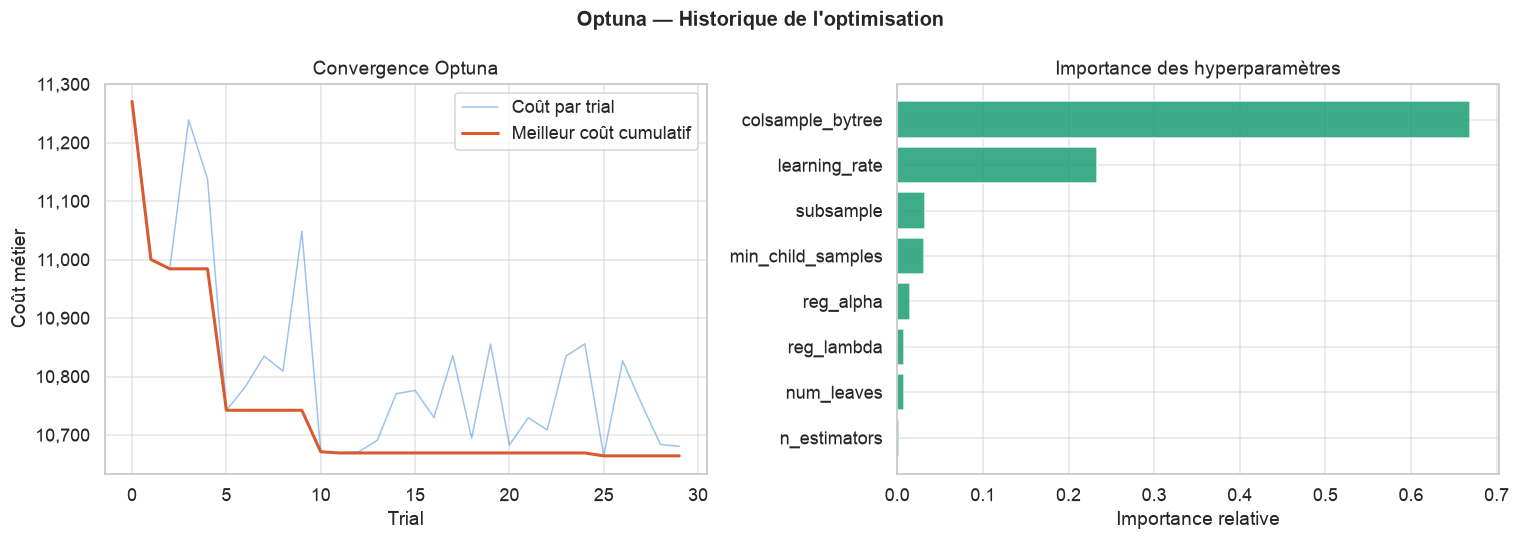

✅ Figure sauvegardée : ./output/figures/optuna_convergence.png


In [7]:
# ── Visualisation Optuna ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optuna — Historique de l'optimisation", fontsize=13, fontweight="bold")

# Convergence
trials_df = study.trials_dataframe()
axes[0].plot(trials_df["number"], trials_df["value"],
             color="#378ADD", alpha=0.5, lw=1, label="Coût par trial")
# Meilleur coût cumulatif
best_cumul = trials_df["value"].cummin()
axes[0].plot(trials_df["number"], best_cumul,
             color="#D85A30", lw=2, label="Meilleur coût cumulatif")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Coût métier")
axes[0].set_title("Convergence Optuna")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
axes[0].legend()

# Importance des hyperparamètres
try:
    importance = optuna.importance.get_param_importances(study)
    params_imp = list(importance.keys())[:8]
    vals_imp   = [importance[p] for p in params_imp]
    axes[1].barh(params_imp[::-1], vals_imp[::-1], color="#1D9E75", alpha=0.85)
    axes[1].set_xlabel("Importance relative")
    axes[1].set_title("Importance des hyperparamètres")
except Exception:
    axes[1].text(0.5, 0.5, "Importance non disponible\n(augmenter N_TRIALS)",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
path_opt = os.path.join(FIGURES_DIR, "optuna_convergence.png")
plt.savefig(path_opt)
plt.show()
print(f"✅ Figure sauvegardée : {path_opt}")


---
## ⚖️ 5. Comparaison GridSearch vs Optuna

On évalue les deux jeux de paramètres sur le **train complet** avec 5 folds.


In [8]:
def evaluer_params(params, nom, X_data, y_data, skf):
    """Évalue un jeu de paramètres avec CV 5 folds sur le train complet."""
    aucs, couts, seuils = [], [], []

    lgbm_params = {k: v for k, v in params.items()
                   if k not in ["class_weight", "random_state", "n_jobs", "verbose"]}
    model = LGBMClassifier(
        **lgbm_params,
        class_weight = "balanced",
        random_state = 42,
        n_jobs       = 1,
        verbose      = -1,
    )

    print(f"\n  Évaluation {nom} (5 folds complets) :")
    for fold, (idx_tr, idx_val) in enumerate(skf.split(X_data, y_data), 1):
        X_tr  = X_data.iloc[idx_tr]
        X_val = X_data.iloc[idx_val]
        y_tr  = y_data.iloc[idx_tr]
        y_val = y_data.iloc[idx_val]

        model.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  callbacks=[early_stopping(50, verbose=False),
                             log_evaluation(-1)])

        y_proba = model.predict_proba(X_val)[:, 1]
        auc     = roc_auc_score(y_val, y_proba)
        seuil, cout, _, _ = seuil_optimal_et_cout(y_val, y_proba)

        aucs.append(auc)
        couts.append(cout)
        seuils.append(seuil)

        print(f"    Fold {fold} — AUC: {auc:.4f} | Coût: {cout:,.0f} | Seuil: {seuil:.3f}")

    res = {
        "AUC"      : np.mean(aucs),
        "AUC_std"  : np.std(aucs),
        "Cout"     : np.mean(couts),
        "Seuil"    : np.mean(seuils),
    }
    print(f"    → AUC   : {res['AUC']:.4f} ± {res['AUC_std']:.4f}")
    print(f"    → Coût  : {res['Cout']:,.0f}")
    print(f"    → Seuil : {res['Seuil']:.3f}")
    return res, model

# ── Évaluation des deux approches ────────────────────────────────
res_grid,   model_grid   = evaluer_params(best_params_grid,   "GridSearch", X, y, SKF)
res_optuna, model_optuna = evaluer_params(best_params_optuna, "Optuna",     X, y, SKF)

# Sélection du meilleur
if res_optuna["Cout"] <= res_grid["Cout"]:
    best_params_final = best_params_optuna
    best_model_final  = model_optuna
    best_res_final    = res_optuna
    methode_gagnante  = "Optuna"
else:
    best_params_final = best_params_grid
    best_model_final  = model_grid
    best_res_final    = res_grid
    methode_gagnante  = "GridSearch"

print(f"\n🏆 Méthode gagnante : {methode_gagnante}")
print(f"   AUC   : {best_res_final['AUC']:.4f}")
print(f"   Coût  : {best_res_final['Cout']:,.0f}")



  Évaluation GridSearch (5 folds complets) :
    Fold 1 — AUC: 0.7716 | Coût: 30,937 | Seuil: 0.528
    Fold 2 — AUC: 0.7770 | Coût: 30,843 | Seuil: 0.525
    Fold 3 — AUC: 0.7704 | Coût: 31,295 | Seuil: 0.518
    Fold 4 — AUC: 0.7762 | Coût: 31,032 | Seuil: 0.525
    Fold 5 — AUC: 0.7673 | Coût: 31,883 | Seuil: 0.531
    → AUC   : 0.7725 ± 0.0036
    → Coût  : 31,198
    → Seuil : 0.525

  Évaluation Optuna (5 folds complets) :
    Fold 1 — AUC: 0.7755 | Coût: 30,718 | Seuil: 0.508
    Fold 2 — AUC: 0.7815 | Coût: 30,253 | Seuil: 0.515
    Fold 3 — AUC: 0.7742 | Coût: 31,031 | Seuil: 0.525
    Fold 4 — AUC: 0.7805 | Coût: 30,660 | Seuil: 0.505
    Fold 5 — AUC: 0.7722 | Coût: 31,510 | Seuil: 0.492
    → AUC   : 0.7768 ± 0.0036
    → Coût  : 30,834
    → Seuil : 0.509

🏆 Méthode gagnante : Optuna
   AUC   : 0.7768
   Coût  : 30,834


---
## 🎯 6. Optimisation du seuil métier

Le seuil par défaut est 0.5 — mais ce n'est **jamais** le seuil optimal pour le scoring crédit.

On trace la courbe **coût métier vs seuil** pour identifier le minimum.


Coût avec seuil 0.5 (défaut)    : 133,212
Coût avec seuil optimal 0.502  : 133,132
Gain en coût                     : 80 (0.1%)


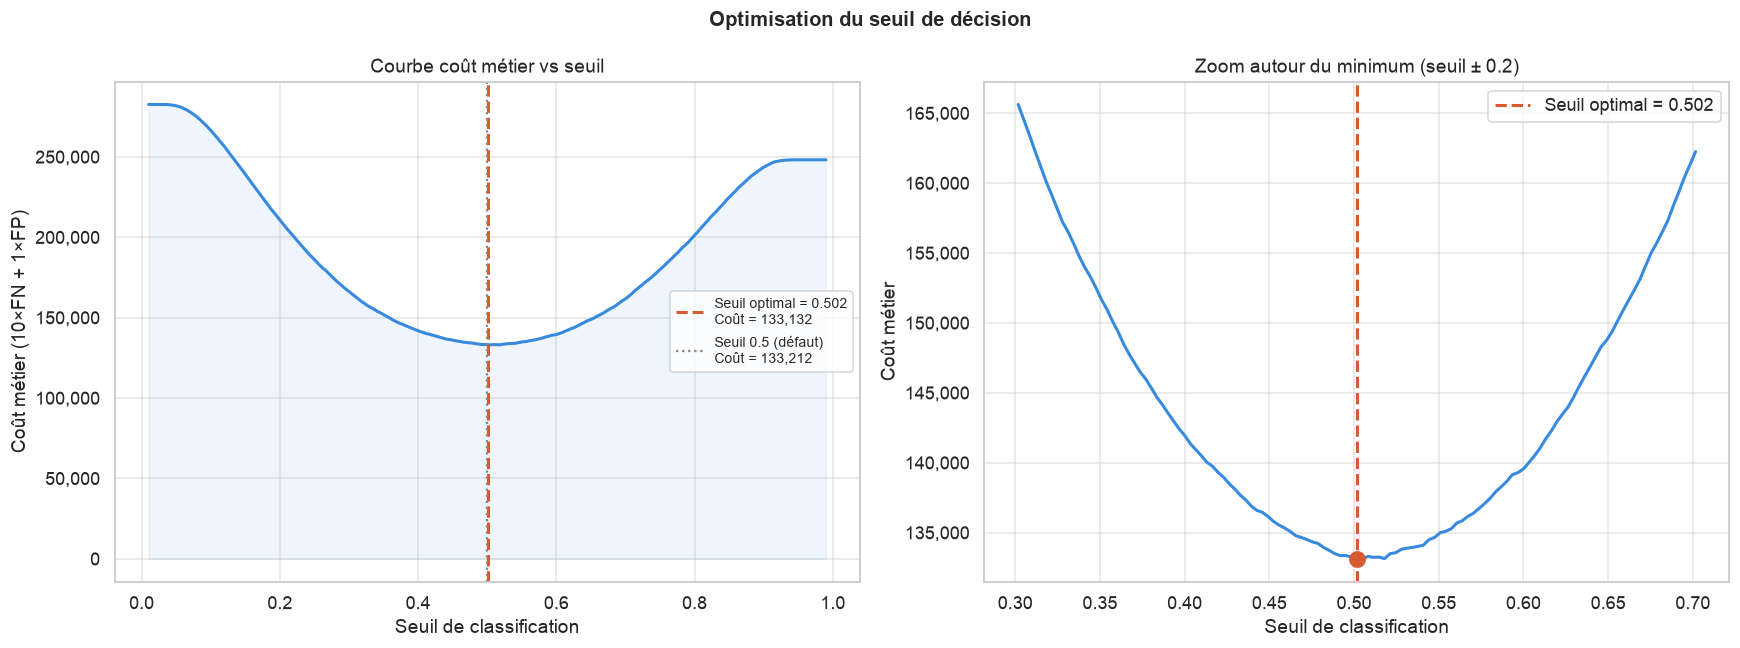

✅ Figure sauvegardée : ./output/figures/seuil_optimal.png


In [9]:
# ── Entraînement final sur tout le train ──────────────────────────
lgbm_final = LGBMClassifier(
    **{k: v for k, v in best_params_final.items()
       if k not in ["class_weight","random_state","n_jobs","verbose"]},
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = 1,
    verbose      = -1,
)
lgbm_final.fit(X, y, callbacks=[log_evaluation(-1)])
y_proba_train = lgbm_final.predict_proba(X)[:, 1]

# ── Courbe coût vs seuil ──────────────────────────────────────────
seuil_opt, cout_opt, seuils_arr, couts_arr = seuil_optimal_et_cout(y, y_proba_train)

# Conversion en numpy arrays pour le masquage
seuils_arr = np.array(seuils_arr)
couts_arr  = np.array(couts_arr)

cout_05 = cout_metier(y, y_proba_train, seuil=0.5)

print(f"Coût avec seuil 0.5 (défaut)    : {cout_05:,.0f}")
print(f"Coût avec seuil optimal {seuil_opt:.3f}  : {cout_opt:,.0f}")
print(f"Gain en coût                     : {cout_05 - cout_opt:,.0f} ({(cout_05-cout_opt)/cout_05*100:.1f}%)")

# ── Graphique ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Optimisation du seuil de décision", fontsize=13, fontweight="bold")

# Courbe coût vs seuil
axes[0].plot(seuils_arr, couts_arr, color="#378ADD", lw=2)
axes[0].axvline(seuil_opt, color="#D85A30", ls="--", lw=2,
                label=f"Seuil optimal = {seuil_opt:.3f}\nCoût = {cout_opt:,.0f}")
axes[0].axvline(0.5, color="#888780", ls=":", lw=1.5,
                label=f"Seuil 0.5 (défaut)\nCoût = {cout_05:,.0f}")
axes[0].fill_between(seuils_arr, couts_arr,
                     alpha=0.08, color="#378ADD")
axes[0].set_xlabel("Seuil de classification")
axes[0].set_ylabel("Coût métier (10×FN + 1×FP)")
axes[0].set_title("Courbe coût métier vs seuil")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
axes[0].legend(fontsize=9)

# Zoom autour du minimum
mask = (seuils_arr > max(0, seuil_opt - 0.2)) & (seuils_arr < min(1, seuil_opt + 0.2))
axes[1].plot(seuils_arr[mask], couts_arr[mask], color="#378ADD", lw=2)
axes[1].axvline(seuil_opt, color="#D85A30", ls="--", lw=2,
                label=f"Seuil optimal = {seuil_opt:.3f}")
axes[1].scatter([seuil_opt], [cout_opt], color="#D85A30", s=100, zorder=5)
axes[1].set_xlabel("Seuil de classification")
axes[1].set_ylabel("Coût métier")
axes[1].set_title(f"Zoom autour du minimum (seuil ± 0.2)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
axes[1].legend()

plt.tight_layout()
path_seuil = os.path.join(FIGURES_DIR, "seuil_optimal.png")
plt.savefig(path_seuil)
plt.show()
print(f"✅ Figure sauvegardée : {path_seuil}")


In [10]:
# ── Analyse détaillée autour du seuil optimal ─────────────────────
seuils_test = np.arange(max(0.05, seuil_opt - 0.15),
                         min(0.95, seuil_opt + 0.15), 0.02)

print(f"{'Seuil':>8} {'FN':>8} {'FP':>8} {'Coût':>10} {'Recall':>8} {'Précision':>10}")
print("-" * 60)

for s in seuils_test:
    y_pred = (y_proba_train >= s).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    cout    = 10*fn + fp
    recall  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec    = tp / (tp + fp) if (tp + fp) > 0 else 0
    flag    = " ← optimal" if abs(s - seuil_opt) < 0.01 else ""
    flag2   = " ← défaut"  if abs(s - 0.5) < 0.01       else ""
    print(f"{s:>8.3f} {fn:>8,} {fp:>8,} {cout:>10,} {recall:>8.3f} {prec:>10.3f}{flag}{flag2}")


   Seuil       FN       FP       Coût   Recall  Précision
------------------------------------------------------------
   0.352    2,256  128,991    151,551    0.909      0.149
   0.372    2,638  120,589    146,969    0.894      0.155
   0.392    3,091  112,443    143,353    0.875      0.162
   0.412    3,547  104,656    140,126    0.857      0.169
   0.432    4,055   97,301    137,851    0.837      0.176
   0.452    4,570   90,119    135,819    0.816      0.184
   0.472    5,122   83,313    134,533    0.794      0.191
   0.492    5,660   76,752    133,352    0.772      0.200 ← optimal ← défaut
   0.512    6,272   70,543    133,263    0.747      0.208
   0.532    6,937   64,557    133,927    0.721      0.217
   0.552    7,616   58,910    135,070    0.693      0.226
   0.572    8,296   53,515    136,475    0.666      0.236
   0.592    9,068   48,277    138,957    0.635      0.246
   0.612    9,837   43,050    141,420    0.604      0.258
   0.632   10,695   38,261    145,211    0.569    

---
## 💾 7. Modèle final & MLflow

On enregistre le modèle optimisé avec ses hyperparamètres et son seuil dans MLflow.


In [11]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("scoring_credit_optimisation")

with mlflow.start_run(run_name=f"LightGBM_optimise_{methode_gagnante}") as run:

    mlflow.set_tags({
        "modele"       : "LightGBM",
        "optimisation" : methode_gagnante,
        "dataset"      : "home_credit",
        "etape"        : "optimisation_hp_seuil",
    })

    # ── Hyperparamètres ───────────────────────────────────────────
    mlflow.log_params(best_params_final)
    mlflow.log_param("methode_optimisation", methode_gagnante)
    mlflow.log_param("n_features",           X.shape[1])
    mlflow.log_param("seuil_defaut",         0.5)
    mlflow.log_param("seuil_optimal",        round(seuil_opt, 4))

    # ── Métriques ─────────────────────────────────────────────────
    mlflow.log_metrics({
        "mean_auc"       : best_res_final["AUC"],
        "std_auc"        : best_res_final["AUC_std"],
        "cout_seuil_05"  : cout_05,
        "cout_seuil_opt" : cout_opt,
        "gain_cout"      : cout_05 - cout_opt,
        "seuil_optimal"  : seuil_opt,
    })

    # ── Artefacts ─────────────────────────────────────────────────
    mlflow.log_artifact(path_seuil, "figures")
    mlflow.log_artifact(path_opt,   "figures")

    # ── Sauvegarde seuil ──────────────────────────────────────────
    seuil_path = os.path.join(OUTPUT_DIR, "seuil_optimal.txt")
    with open(seuil_path, "w") as f:
        f.write(str(round(seuil_opt, 4)))
    mlflow.log_artifact(seuil_path)

    # ── Log modèle ────────────────────────────────────────────────
    mlflow.lightgbm.log_model(
        lgbm_final,
        artifact_path         = "model",
        registered_model_name = "scoring_credit_lgbm_optimise",
        input_example         = X.head(3),
    )

    RUN_ID = run.info.run_id
    print(f"✅ Run ID : {RUN_ID}")
    print(f"   Modèle : scoring_credit_lgbm_optimise")

# ── Rapport final ─────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════════════╗
║       RAPPORT — Étape 4 : Optimisation                      ║
╠══════════════════════════════════════════════════════════════╣
║  Méthode gagnante     : {methode_gagnante:<34}║
║  AUC final            : {best_res_final['AUC']:.4f} ± {best_res_final['AUC_std']:.4f}                  ║
║  Seuil défaut (0.5)   : coût = {cout_05:>10,.0f}                  ║
║  Seuil optimal        : {seuil_opt:.3f}  coût = {cout_opt:>10,.0f}            ║
║  Gain coût            : {cout_05-cout_opt:>10,.0f} ({(cout_05-cout_opt)/cout_05*100:.1f}%)              ║
╠══════════════════════════════════════════════════════════════╣
║  Prochaine étape      : Interprétabilité SHAP               ║
╚══════════════════════════════════════════════════════════════╝""")


2026/08/01 02:07:32 INFO mlflow.tracking.fluent: Experiment with name 'scoring_credit_optimisation' does not exist. Creating a new experiment.
2026/08/01 02:07:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Run ID : 9be1dfe48f454c8cad01050019a44f4f
   Modèle : scoring_credit_lgbm_optimise

╔══════════════════════════════════════════════════════════════╗
║       RAPPORT — Étape 4 : Optimisation                      ║
╠══════════════════════════════════════════════════════════════╣
║  Méthode gagnante     : Optuna                            ║
║  AUC final            : 0.7768 ± 0.0036                  ║
║  Seuil défaut (0.5)   : coût =    133,212                  ║
║  Seuil optimal        : 0.502  coût =    133,132            ║
║  Gain coût            :         80 (0.1%)              ║
╠══════════════════════════════════════════════════════════════╣
║  Prochaine étape      : Interprétabilité SHAP               ║
╚══════════════════════════════════════════════════════════════╝


Successfully registered model 'scoring_credit_lgbm_optimise'.
Created version '1' of model 'scoring_credit_lgbm_optimise'.


In [12]:
import json
import os

# ── Dossier de sortie (model/ à la racine du repo, notebook dans notebooks/) ─
MODEL_DIR = "../../model"
os.makedirs(MODEL_DIR, exist_ok=True)

# ── 1. Modèle LightGBM (format natif) ───────────────────────────────
lgbm_final.booster_.save_model(os.path.join(MODEL_DIR, "lgbm_model.txt"))

# ── 2. Liste des features, dans l'ordre exact d'entraînement ────────
with open(os.path.join(MODEL_DIR, "features.json"), "w") as f:
    json.dump(TOP_200, f, indent=2)

# ── 3. Seuil de décision optimal ─────────────────────────────────────
with open(os.path.join(MODEL_DIR, "threshold.json"), "w") as f:
    json.dump({"seuil_optimal": round(seuil_opt, 4)}, f, indent=2)

# ── 4. Métadonnées ────────────────────────────────────────────────────
metadata = {
    "model_name": "scoring_credit_lgbm_optimise",
    "n_features": len(TOP_200),
    "seuil_optimal": round(seuil_opt, 4),
    "mean_auc": round(float(best_res_final["AUC"]), 4),
    "methode_optimisation": methode_gagnante,
}
with open(os.path.join(MODEL_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Export terminé :")
print(f"   - {MODEL_DIR}/lgbm_model.txt")
print(f"   - {MODEL_DIR}/features.json  ({len(TOP_200)} features)")
print(f"   - {MODEL_DIR}/threshold.json (seuil = {seuil_opt:.4f})")
print(f"   - {MODEL_DIR}/metadata.json")

✅ Export terminé :
   - ../model/lgbm_model.txt
   - ../model/features.json  (200 features)
   - ../model/threshold.json (seuil = 0.5016)
   - ../model/metadata.json


---
## ✅ Étape 4 terminée

**Ce qui a été réalisé :**
- GridSearchCV sur la grille d'hyperparamètres (AUC-ROC)
- Optuna TPE sur 30 trials optimisant directement le coût métier
- Comparaison des deux approches sur 5 folds complets
- Courbe coût vs seuil tracée et seuil optimal identifié
- Modèle final enregistré dans MLflow avec seuil sauvegardé

**Prochaine étape :** Interprétabilité avec SHAP (feature importance globale et locale)
